# Лабораторная 2: LSTM для задачи many-to-many

**Навигация:** Блок `01-RNN` · `ЛР02` · Шаг 2 курса

## Цель
Построить `LSTM`-модель, которая выдает бинарную метку на каждом шаге времени.

Формат `many-to-many` означает: на каждом временном шаге формируется собственное предсказание.


## Что нужно знать до старта

Вы сейчас здесь: `01-RNN / ЛР02` — локальная ЛР02 блока `RNN`, Шаг 2 курса.
Предыдущий шаг: `01-RNN / ЛР01`.
Следующий шаг: `01-RNN / ЛР03`.

Перед ноутбуком полезно пройти:
- [Foundations entry-point](../../00-Foundations/README.md)
- [Shared-guide по формам и метрикам](../../00-Foundations/guides/01_sequence_shapes_and_metrics.md)
- [База по обозначениям и формам](guides/00_prerequisites_and_notation.md)
- [Beginner guide к LSTM many-to-many](guides/02_lstm_many_to_many_beginner.md)

Если идёте без преподавателя, добавьте ещё:
- [walkthrough](guides/02_lstm_walkthrough.md)
- [shared debugging playbook](../../00-Foundations/guides/04_self_study_debugging_playbook.md)

Что важно помнить:
- теперь ответ нужен на каждом шаге времени, а не один раз в конце;
- поэтому LSTM должна вернуть всю последовательность скрытых состояний, то есть `return_sequences=True`;
- в этой лабораторной `token_accuracy` означает точность по шагам последовательности, а не NLP tokenization;
- одна ошибка на одном шаге может испортить всю последовательность в метрике `sequence_accuracy`.

## Выбор runtime

Здесь вы выбираете, где и на чём запускать notebook.

Что обычно выбирать:
- `auto` — лучший вариант по умолчанию. Если TensorFlow видит GPU, будет выбран GPU. Если GPU нет, notebook спокойно останется на CPU.
- `local-cpu` — локальный запуск только на CPU, даже если видеокарта есть.
- `local-gpu` — локальный запуск с обязательным GPU. Если GPU не настроен, notebook специально остановится с понятной ошибкой.
- `colab-cpu` / `colab-gpu` — запуск в Google Colab.
- `kaggle-cpu` / `kaggle-gpu` — запуск в Kaggle Notebooks.

Что важно:
- после изменения `RUNTIME_MODE` используйте `Restart & Run All`;
- `COURSE_REPO_HTTPS_URL` нужен только для Colab/Kaggle, если репозиторий ещё не клонирован в runtime;
- пока в ячейке стоит placeholder-URL, cloud auto-bootstrap не сможет сам скачать курс;
- guide `05` отвечает на вопрос, где и как запускать notebook;
- guide `06` нужен, если вы хотите именно локальный GPU и не уверены в версиях `TensorFlow` / `CUDA`;
- локальный GPU-path курса: `Linux + NVIDIA` или `Windows -> WSL2 + Ubuntu`;
- если `local-gpu` упирается в локальные CUDA/PTX ошибки, это обычно уже проблема GPU-стека, а не notebook. В таком случае спокойно переключайтесь на `local-cpu`, `colab-gpu` или `kaggle-gpu`.

Подробные guides:
- `themes/00-Foundations/guides/05_local_tensorflow_gpu_notebooks.md`
- `themes/00-Foundations/guides/06_tensorflow_cuda_version_selection.md`


In [2]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

RUNTIME_MODE = os.environ.get("COURSE_RUNTIME_MODE", "auto")
COURSE_REPO_HTTPS_URL = os.environ.get(
    "COURSE_REPO_HTTPS_URL",
    "https://github.com/<org>/<repo>.git",
)
NOTEBOOK_REQUIREMENTS = "themes/01-RNN/lab/requirements.txt"


def _detect_notebook_platform():
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle").exists():
        return "kaggle"
    if os.environ.get("COLAB_RELEASE_TAG") or "google.colab" in sys.modules:
        return "colab"
    return "local"


def _looks_like_repo_root(path: Path) -> bool:
    return (
        path.is_dir()
        and (path / "themes").is_dir()
        and (path / "course_runtime.py").is_file()
    )


def _canonical_cloud_repo_root(platform: str) -> Path:
    if platform == "colab":
        return Path("/content/students-AI_math_essentials")
    if platform == "kaggle":
        return Path("/kaggle/working/students-AI_math_essentials")
    raise ValueError(f"Unexpected cloud platform: {platform}")


def _is_placeholder_repo_url(repo_url: str) -> bool:
    return repo_url.strip() == "https://github.com/<org>/<repo>.git"


def _find_repo_root_from_cwd():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if _looks_like_repo_root(candidate):
            return candidate
    return None


def _ensure_course_runtime_importable(runtime_mode: str, repo_url: str) -> None:
    if importlib.util.find_spec("course_runtime") is not None:
        return

    local_repo_root = _find_repo_root_from_cwd()
    if local_repo_root is not None:
        if str(local_repo_root) not in sys.path:
            sys.path.insert(0, str(local_repo_root))
        return

    platform = _detect_notebook_platform()
    if platform == "local":
        raise ModuleNotFoundError(
            "Не удалось импортировать course_runtime.py. Для локального запуска "
            "открывайте репозиторий через `.venv/bin/jupyter notebook` из корня проекта."
        )

    repo_root = _canonical_cloud_repo_root(platform)
    if not _looks_like_repo_root(repo_root):
        if _is_placeholder_repo_url(repo_url):
            raise RuntimeError(
                "Для cloud auto-bootstrap нужен публичный HTTPS URL курса. "
                "Замените COURSE_REPO_HTTPS_URL на реальный адрес репозитория."
            )
        repo_root.parent.mkdir(parents=True, exist_ok=True)
        if repo_root.exists() and any(repo_root.iterdir()):
            raise RuntimeError(
                f"Каталог {repo_root} уже существует, но не выглядит как корень курса. "
                "Очистите runtime или используйте новый notebook session."
            )
        print(f"Bootstrapping course repository into {repo_root} ...")
        subprocess.run(["git", "clone", repo_url, str(repo_root)], check=True)

    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))


#_ensure_course_runtime_importable(RUNTIME_MODE, COURSE_REPO_HTTPS_URL)
#
#from course_runtime import setup_notebook_runtime
#
#runtime_info = setup_notebook_runtime(
#    runtime_mode=RUNTIME_MODE,
#    course_repo_https_url=COURSE_REPO_HTTPS_URL,
#    notebook_requirements=NOTEBOOK_REQUIREMENTS,
#)
#runtime_info.as_dict()


## Интуиция задачи без формул

Теперь модель должна отвечать не один раз в конце, а после каждого нового элемента входа. После первого шага она знает только первый элемент. После второго шага она знает сумму первых двух. После третьего шага сумму первых трёх, и так далее.

Поэтому задача many-to-many отличается от many-to-one не только метриками, но и формой выхода: на каждом шаге нужен свой локальный прогноз. Именно ради этого мы просим LSTM вернуть последовательность скрытых состояний, а не только последнее.


## Как проходить эту ЛР без преподавателя

Рекомендуемый self-study маршрут:
1. Прочитайте [пререквизиты](guides/00_prerequisites_and_notation.md), [beginner guide](guides/02_lstm_many_to_many_beginner.md), [walkthrough](guides/02_lstm_walkthrough.md) и [debugging playbook](guides/00_self_study_debugging_playbook.md).
2. Двигайтесь строго сверху вниз и не пропускайте мини-проверки после каждого `TODO`.
3. Если застряли на одном шаге, открывайте walkthrough только для текущего блока, а не для всей ЛР сразу.
4. [Solution notebook](solutions/02_lstm_many_to_many_toy_solution.ipynb) используйте только после собственной попытки и ручной проверки форм.
5. Если notebook запутался в старом состоянии, используйте `Restart & Run All`.


## Что изменилось после `01-RNN / ЛР01`

Переход от `many-to-one` к `many-to-many` меняет не только архитектуру, но и способ читать задачу:
- раньше нас интересовал один итоговый ответ на всю последовательность;
- теперь нужен отдельный ответ на каждом шаге времени;
- из-за этого меняются форма `y`, форма выхода модели и логика метрик.

Главный практический вывод: без `return_sequences=True` эта лабораторная не решается, потому что модель вернёт только один итоговый вектор вместо временной карты ответов.


## Контракт данных
Используется учебная синтетическая постановка:
- вход: последовательность из `-1` и `+1`;
- метка на шаге `t` равна `1`, если кумулятивная сумма `x_1 + ... + x_t` строго положительна, иначе `0`.

Таким образом, правильная метка каждого шага зависит от предыдущей истории.


## Таблица форм тензоров

| Тензор | Форма | Смысл | Где используется |
|---|---|---|---|
| `X` | `(N, T, 1)` | Входные последовательности | Генерация данных |
| `cumsum` | `(N, T)` | Промежуточная кумулятивная сумма | Генерация меток |
| `y` | `(N, T, 1)` | Метки для каждого шага | Обучение и оценка |
| `probs` | `(N_test, T, 1)` | Вероятности класса по шагам | `model.predict` |
| `preds` | `(N_test, T, 1)` | Бинарные предсказания по шагам | Оценка |
| `token_accuracy` | скаляр | Доля верных токенов | Метрика модели |
| `sequence_accuracy` | скаляр | Доля полностью верных последовательностей | Доп. метрика |


## Шпаргалка по обозначениям и формам

Короткая карта обозначений:
- `N` - размер батча.
- `T` - длина последовательности.
- `x_t` - элемент входа на шаге `t`.
- `s_t` - накопленная сумма на префиксе `x_1 ... x_t`.
- `y_t` - правильная метка на шаге `t`: стала ли текущая сумма строго положительной.
- `h_t` - скрытое состояние LSTM на шаге `t`.

Формы тензоров:
- `X_train`: `(N, T, 1)`.
- `y_train`: `(N, T, 1)`.
- выход модели: `(batch, T, 1)`.
- `token_accuracy` в этой ЛР = точность по отдельным шагам времени, а не по текстовым токенам.
- `sequence_accuracy` засчитывает пример только если все шаги последовательности предсказаны правильно.


## Контракт модели
- В `model.fit` передается `X_train` и `y_train` одинаковой длины по времени.
- Рекуррентный слой должен возвращать всю последовательность состояний (`return_sequences=True`).
- Выход `model.predict` имеет ту же временную длину, что и вход.
- Потеря: бинарная кросс-энтропия (`binary_crossentropy`) по всем временным шагам.


### Почему без return_sequences=True задача не решается

В `many-to-many` модель должна вернуть ответ на каждом временном шаге. Если `LSTM` оставить с настройкой по умолчанию, она вернёт только последнее состояние формы `(batch, units)`.

Этого недостаточно: такой выход подходит для `many-to-one`, но не даёт отдельного ответа на каждый шаг. Параметр `return_sequences=True` заставляет `LSTM` вернуть форму `(batch, time, units)`, после чего `Dense(1)` может построить выход `(batch, T, 1)`.


## Мини-теория
В канонической нотации `LSTM`:

$$
u_t=[h_{t-1};x_t], \quad
f_t = \sigma(W_f u_t + b_f), \quad
i_t = \sigma(W_i u_t + b_i), \quad
\tilde{c}_t = \tanh(W_c u_t + b_c), \quad
o_t = \sigma(W_o u_t + b_o)
$$

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t, \quad
h_t = o_t \odot \tanh(c_t), \quad
s_t = W_{hy}h_t + b_y, \quad
\hat{y}_t = \sigma(s_t)
$$

Формат `many-to-many` реализуется через выдачу предсказаний на каждом шаге времени.


## Ручной разбор одного примера

Возьмём последовательность `[+1, -1, +1, +1]`.

Считаем накопленную сумму на каждом шаге:
- шаг 1: сумма `1`, метка `1`
- шаг 2: сумма `0`, метка `0`
- шаг 3: сумма `1`, метка `1`
- шаг 4: сумма `2`, метка `1`

Значит целевая последовательность меток равна `[1, 0, 1, 1]`. Здесь важно видеть разницу с ЛР1: нас интересует не только финальная сумма, а правильный ответ на каждом префиксе.


In [3]:
seq = [1, -1, 1, 1]
running_sum = 0
labels = []

print('sequence:', seq)
for step, value in enumerate(seq, start=1):
    running_sum += value
    label = int(running_sum > 0)
    labels.append(label)
    print(f'step {step}: value={value:+d}, running_sum={running_sum:+d}, label={label}')

print('target labels:', labels)


sequence: [1, -1, 1, 1]
step 1: value=+1, running_sum=+1, label=1
step 2: value=-1, running_sum=+0, label=0
step 3: value=+1, running_sum=+1, label=1
step 4: value=+1, running_sum=+2, label=1
target labels: [1, 0, 1, 1]


In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed(42)
print('Версия TensorFlow:', tf.__version__)

Версия TensorFlow: 2.21.0


## Генерация данных
**Что сделать:** построить покадровые метки на основе кумулятивной суммы.

**Почему:** каждая метка должна зависеть от предыдущих шагов.

**Ожидаемые формы:** `X -> (N,T,1)`, `y -> (N,T,1)`.

**Частая ошибка:** формировать `y` как `(N,T)` без последней оси.


### Подсказка к TODO 1-2: данные

Концептуальная подсказка:
- теперь метка нужна на каждом шаге, поэтому `y` должен сохранить временную ось.

Implementation hint:
- сначала удобно получить `cumsum` формы `(N, T)`;
- затем вернуть ось признака и получить `y` формы `(N, T, 1)`;
- в этой ЛР класс `1` ставится при строгом `cumsum > 0`.

Если застряли, откройте раздел про TODO 1-2 в [walkthrough](guides/02_lstm_walkthrough.md).


In [5]:
def make_dataset(n_samples: int = 6500, seq_len: int = 16):
    x = np.random.choice([-1.0, 1.0], size=(n_samples, seq_len, 1)).astype(np.float32)
    # TODO 1: посчитайте кумулятивную сумму по временной оси
    cumsum = np.cumsum(x[:, :, 0], axis=1)
    # TODO 2: сформируйте бинарные метки формы (N,T,1)
    y = (cumsum > 0).astype(np.float32).reshape(-1, seq_len, 1)
    return x, y, cumsum


X, y, cumsum = make_dataset()
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print('Форма X_train:', X_train.shape)
print('Форма y_train:', y_train.shape)
print('Форма X_test :', X_test.shape)
print('Форма y_test :', y_test.shape)

Форма X_train: (5200, 16, 1)
Форма y_train: (5200, 16, 1)
Форма X_test : (1300, 16, 1)
Форма y_test : (1300, 16, 1)


### Разбор TODO 1-2: данные

После заполнения кода проверьте себя по признакам корректного результата:
- `cumsum` имеет форму `(N, T)`;
- `y` имеет форму `(N, T, 1)`;
- на ручном примере можно показать, где именно появляется класс `0`, если накопленная сумма не стала положительной.


In [6]:
# Мини-проверка данных
assert X.ndim == 3 and X.shape[-1] == 1, 'Ожидается X формы (N,T,1)'
assert y.ndim == 3 and y.shape[-1] == 1, 'Ожидается y формы (N,T,1)'
assert cumsum.shape == X[:, :, 0].shape, 'Форма cumsum должна быть (N,T)'
print('Мини-проверка данных: OK')

Мини-проверка данных: OK


### Что должно получиться после шага "Данные"

Ожидаемые сигналы:
- `X` имеет форму `(N, T, 1)`;
- `cumsum` имеет форму `(N, T)`;
- `y` имеет форму `(N, T, 1)`;
- мини-проверка данных проходит без ошибок.

Self-check checkpoint:
- выберите одну последовательность;
- посчитайте накопленную сумму по шагам;
- вручную восстановите целевую последовательность меток и сравните её с `y`.


## Модель
**Что сделать:** собрать `Sequential`-модель с `LSTM(return_sequences=True)`.

**Почему:** нужен выход на каждом временном шаге.

**Ожидаемая форма выхода:** `(batch, T, 1)`.


### Подсказка к TODO 3-4: модель

Концептуальная подсказка:
- теперь нужен ответ на каждом шаге времени, а значит временная ось должна остаться в выходе модели.

Implementation hint:
- используйте `LSTM(..., return_sequences=True)`;
- завершите модель `Dense(1, activation='sigmoid')`;
- скомпилируйте её как бинарную классификацию.

Если вы получили `(batch, units)` вместо `(batch, T, 1)`, откройте [walkthrough](guides/02_lstm_walkthrough.md).


In [7]:
def build_model(input_shape):
    model = tf.keras.Sequential(name='lstm_many_to_many')
    model.add(tf.keras.layers.Input(shape=input_shape))
    # TODO 3: добавьте слой LSTM с return_sequences=True
    model.add(tf.keras.layers.LSTM(16, return_sequences=True))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    # TODO 4: скомпилируйте модель (adam, binary_crossentropy, accuracy)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


model = build_model(X_train.shape[1:])
model.summary()

Model: "lstm_many_to_many"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16, 16)         │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16, 1)          │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,169 (4.57 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

### Разбор TODO 3-4: модель

После заполнения блока проверьте, что вы можете объяснить не только код, но и форму выхода:
- почему здесь нужен `return_sequences=True`;
- почему `Dense(1)` применяется после временной оси;
- почему мини-проверка сравнивает `model.output_shape[1:]` именно с `y_train.shape[1:]`.


In [8]:
# Мини-проверка модели
assert model.output_shape[1:] == y_train.shape[1:], 'Форма выхода должна совпадать с формой y'
print('Мини-проверка модели: OK')

Мини-проверка модели: OK


### Что должно получиться после шага "Модель"

Ожидаемые сигналы:
- `model.summary()` показывает `LSTM(..., return_sequences=True)`;
- форма выхода совпадает с `y_train.shape[1:]`;
- мини-проверка модели проходит.

Self-check checkpoint:
- представьте один батч из 64 последовательностей длины `T`;
- объясните, почему модель должна вернуть форму `(64, T, 1)`, а не `(64, 1)`.


## Трассировка одного примера через модель
Проверка форм тензоров:
1. входной пример;
2. выход `LSTM`-слоя на всех шагах;
3. итоговый выходной слой.


In [9]:
sample_x = X_train[:1]
_ = model(sample_x)

lstm_features_model = tf.keras.Model(inputs=model.inputs[0], outputs=model.layers[-2].output)
lstm_features = lstm_features_model.predict(sample_x, verbose=0)

sample_prob = model.predict(sample_x, verbose=0)

print('Вход sample_x      :', sample_x.shape)
print('После LSTM         :', lstm_features.shape)
print('После выходного слоя:', sample_prob.shape)
print('Первые 3 вероятности:', sample_prob[0, :3, 0])

Вход sample_x      : (1, 16, 1)
После LSTM         : (1, 16, 16)
После выходного слоя: (1, 16, 1)
Первые 3 вероятности: [0.49523124 0.5026593  0.50514805]


## Как идет обучение внутри эпохи
Для каждого мини-батча:
1. прямой проход (`forward pass`) по всем шагам;
2. вычисление покадровой функции потерь;
3. обратное распространение через время (`BPTT`);
4. обновление параметров.

Для `LSTM` поток градиента стабилизируется за счет памяти `c_t` и ворот `f_t`, `i_t`, `o_t`, поэтому обычно легче обучать зависимости средней и большой длины.


## Обучение
Обучение выполняется с `validation_split=0.2` на обучающей части. Контрольная выборка `test` не участвует в подборе параметров.


### Подсказка к TODO 5: обучение

Концептуальная подсказка:
- этот шаг почти такой же, как в ЛР1, меняется не вызов `fit`, а смысл метрик внутри истории.

Implementation hint:
- используйте `validation_split=0.2`, `batch_size=64` и аргумент `epochs`;
- после запуска проверьте, что `history.history` содержит `val_loss` и `val_accuracy`.

Если застряли, откройте [debugging playbook](guides/00_self_study_debugging_playbook.md).


In [10]:
def train_model(model, X_train, y_train, epochs: int = 12):
    # TODO 5: обучите модель с validation_split=0.2 и batch_size=64
    history = model.fit(X_train, y_train, validation_split=0.2, batch_size=64, epochs=epochs)
    return history


history = train_model(model, X_train, y_train)

Epoch 1/12
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6855 - loss: 0.6251 - val_accuracy: 0.7957 - val_loss: 0.5324
Epoch 2/12
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9039 - loss: 0.4378 - val_accuracy: 0.9180 - val_loss: 0.3772
Epoch 3/12
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9159 - loss: 0.3228 - val_accuracy: 0.9129 - val_loss: 0.2864
Epoch 4/12
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9290 - loss: 0.2497 - val_accuracy: 0.9482 - val_loss: 0.2221
Epoch 5/12
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9556 - loss: 0.1920 - val_accuracy: 0.9646 - val_loss: 0.1690
Epoch 6/12
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9795 - loss: 0.1488 - val_accuracy: 0.9901 - val_loss: 0.1335
Epoch 7/12
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9948 - loss: 0.1202 - val_accuracy: 0.9981 - val_loss: 0.1093
Epoch 8/12
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9983 - loss: 0.0993 - val_accuracy: 0.9994 - val_loss:

### Разбор TODO 5: обучение

После заполнения блока проверьте, что вы не ждёте от истории лишнего:
- на этом шаге вы ещё не видите `sequence_accuracy`;
- история показывает только те метрики, которые модель знает во время `compile`.


In [11]:
# Мини-проверка обучения
assert 'val_loss' in history.history and 'val_accuracy' in history.history
print('Последняя val_accuracy:', float(history.history['val_accuracy'][-1]))
print('Мини-проверка обучения: OK')

Последняя val_accuracy: 0.9998196959495544
Мини-проверка обучения: OK


### Что должно получиться после шага "Обучение"

Ожидаемые сигналы:
- в `history.history` есть `loss`, `val_loss`, `accuracy`, `val_accuracy`;
- `val_accuracy` растёт по шагам времени лучше случайного уровня;
- вы понимаете, что строгая `sequence_accuracy` будет считаться позже вручную.

Self-check checkpoint:
- можете ли вы объяснить, почему хорошая `val_accuracy` ещё не гарантирует высокую `sequence_accuracy`?


## Оценка и диагностика
Считаются две метрики:
- `token_accuracy`: доля корректных шагов времени;
- `sequence_accuracy`: доля последовательностей, где корректны все шаги.

Вторая метрика более строгая и чувствительна к единичным ошибкам.


## Ручная таблица: preds vs y_true по шагам

Удобно один раз выписать сравнение буквально по шагам:

| Шаг | `y_true` | `preds` | Совпадение |
|---|---|---|---|
| 1 | `1` | `1` | да |
| 2 | `0` | `0` | да |
| 3 | `1` | `1` | да |
| 4 | `1` | `0` | нет |

Такая таблица помогает не путать две логики сразу:
- локальную точность по шагам времени;
- строгую точность по всей последовательности.


## Worked example: одна ошибка ломает sequence_accuracy

Пусть модель предсказала 3 шага из 4 правильно. Тогда:
- локально это уже неплохой результат;
- но для `sequence_accuracy` объект всё равно считается неверным.

Пример:
- `y_true = [1, 0, 1, 1]`
- `preds  = [1, 0, 1, 0]`

Тогда:
- `token_accuracy = 0.75`
- `sequence_accuracy = 0`

Именно поэтому в ЛР2 нельзя делать вывод о качестве только по `token_accuracy`.


### Подсказка к TODO 6-7: метрики

Концептуальная подсказка:
- здесь мало просто получить `preds`; нужно ещё понять, когда вся последовательность считается правильной.

Implementation hint:
- примените порог `0.5` к `probs`;
- сравните `preds` и `y_test` по всем временным шагам;
- для `sequence_accuracy` проверьте, что у одного объекта совпали все элементы по осям времени и признака.

Если застряли, откройте [walkthrough](guides/02_lstm_walkthrough.md).


In [12]:
def evaluate_model(model, X_test, y_test):
    loss, token_acc = model.evaluate(X_test, y_test, verbose=0)
    probs = model.predict(X_test, verbose=0)
    # TODO 6: преобразуйте вероятности в бинарные предсказания порогом 0.5
    preds = (probs > 0.5).astype(int)
    # TODO 7: вычислите sequence_accuracy как долю полностью верных последовательностей
    seq_acc = (preds == y_test).all(axis=(1, 2)).mean()
    return {
        'loss': float(loss),
        'token_accuracy': float(token_acc),
        'sequence_accuracy': float(seq_acc),
        'probs': probs,
        'preds': preds,
    }


metrics = evaluate_model(model, X_test, y_test)
print({k: v for k, v in metrics.items() if k in ('loss', 'token_accuracy', 'sequence_accuracy')})

{'loss': 0.04722290113568306, 'token_accuracy': 0.9998557567596436, 'sequence_accuracy': 0.9976923076923077}


### Разбор TODO 6-7: метрики

После заполнения блока проверьте смысл двух разных метрик:
- `token_accuracy` отвечает за локальные шаги времени;
- `sequence_accuracy` отвечает за полностью верные последовательности;
- одна локальная ошибка может почти не испортить первую метрику, но полностью обнулить вклад объекта во вторую.


In [13]:
# Мини-проверка метрик
assert 0.0 <= metrics['token_accuracy'] <= 1.0
assert 0.0 <= metrics['sequence_accuracy'] <= 1.0
if metrics['token_accuracy'] >= 0.90:
    print('Целевой порог достигнут: token_accuracy >= 0.90')
else:
    print('Целевой порог не достигнут: проверьте формы данных и параметры обучения')

Целевой порог достигнут: token_accuracy >= 0.90


### Что должно получиться после шага "Метрики"

Ожидаемые сигналы:
- `token_accuracy` и `sequence_accuracy` лежат в диапазоне `[0, 1]`;
- `token_accuracy` обычно оказывается выше `sequence_accuracy`;
- вы можете вручную объяснить, как считалась каждая из двух метрик.

Self-check checkpoint:
- выберите одну маленькую последовательность;
- сравните `preds` и `y_true` по шагам;
- отдельно объясните, какой вклад этот объект вносит в `token_accuracy` и в `sequence_accuracy`.


## Как читать графики и метрики

Здесь полезно смотреть сразу на две разные картины качества:
- `token_accuracy` показывает, как часто модель угадывает отдельный шаг последовательности;
- `sequence_accuracy` показывает, как часто вся последовательность угадана целиком.

Поэтому нормальна ситуация, когда `token_accuracy` уже высокая, а `sequence_accuracy` заметно ниже. Одной локальной ошибки достаточно, чтобы пример не засчитался как полностью правильный.

Если графики растут, но `sequence_accuracy` отстаёт слишком сильно, стоит проверить сложные позиции в конце последовательности: именно там ошибка префиксной логики чаще всего ломает весь пример.


## Что ожидать на практике
- `token_accuracy` обычно растет быстрее `sequence_accuracy`.
- Если `token_accuracy` высокая, а `sequence_accuracy` низкая, модель ошибается в отдельных шагах.
- Резкий разрыв между train и validation может указывать на переобучение.
- Для корректной реализации ожидается достижение `token_accuracy >= 0.90`.


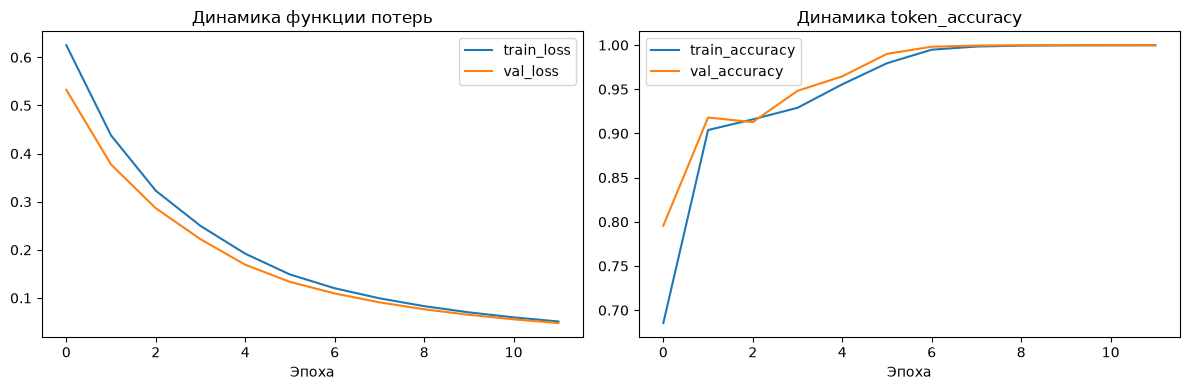

In [14]:
# Визуализация динамики обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Динамика функции потерь')
plt.xlabel('Эпоха')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Динамика token_accuracy')
plt.xlabel('Эпоха')
plt.legend()

plt.tight_layout()
plt.show()

## Если не получилось с первого раза

Идите по короткому маршруту, а не пытайтесь чинить всё сразу:
1. Если не сходятся формы, вернитесь в [пререквизиты](guides/00_prerequisites_and_notation.md).
2. Если путаетесь в `many-to-many` и `return_sequences=True`, откройте [beginner guide](guides/02_lstm_many_to_many_beginner.md).
3. Если не получается конкретный `TODO`, откройте [walkthrough](guides/02_lstm_walkthrough.md).
4. Если развалился notebook state или traceback неясен, используйте [debugging playbook](guides/00_self_study_debugging_playbook.md).
5. Только потом сверяйтесь с solution notebook блок за блоком.


## Если застряли: порядок диагностики

Порядок проверки лучше держать простым: сначала данные, потом формы тензоров, потом модель, и только после этого метрики и визуализации.

1. Проверьте целевую последовательность: на каждом шаге метка должна точно соответствовать правилу `cumsum > 0`.
2. Проверьте форму `y`: ожидается `(N, T, 1)`.
3. Убедитесь, что у LSTM включён `return_sequences=True`, иначе модель не сможет выдавать ответ на каждом шаге.
4. Не путайте `token_accuracy` с tokenization: здесь это просто точность по шагам времени.
5. Разберите один пример вручную и найдите первый шаг, где модель начала ошибаться.


## Чек-лист перед сдачей

- Понимаю, почему здесь нужен ответ на каждом шаге.
- Могу объяснить, зачем нужен `return_sequences=True`.
- Проверил форму `y` как `(N, T, 1)`.
- Не путаю `token_accuracy` с tokenization.
- Могу показать на ручном примере, почему одна локальная ошибка портит `sequence_accuracy`.


## Как использовать решение без самообмана

Когда дойдёте до [solution notebook](solutions/02_lstm_many_to_many_toy_solution.ipynb), используйте его так:
1. Не открывайте всё решение заранее.
2. Найдите конкретный шаг, где вы застряли.
3. Сравните только этот блок, а потом закройте решение и допишите свой notebook сами.
4. После исправления снова прогоните мини-проверки и убедитесь, что понимаете, почему они стали зелёными.

Цель решения — не заменить вашу попытку, а помочь восстановить её осмысленно.


## Мини-экзамен

1. Что изменилось после ЛР1 на уровне форм целевого тензора?
2. Почему для ЛР2 критичен `return_sequences=True`?
3. Почему `y` должно иметь форму `(N, T, 1)`, а не `(N, T)`?
4. Что именно измеряет `token_accuracy`?
5. Как мысленно считается `sequence_accuracy`?
6. Почему одна локальная ошибка может почти не испортить `token_accuracy`, но занулить вклад объекта в `sequence_accuracy`?


## Что дальше

Следующий шаг курса: Шаг 3 = `01-RNN / ЛР03`.

Там формат снова усложняется:
- появится словарь дискретных токенов;
- модель начнёт генерировать новую последовательность, а не только ставить метки входу;
- понадобятся `PAD`, `SOS`, `EOS`, `Embedding`, `teacher forcing` и строгая метрика `exact_match`.


## Вопросы для самопроверки
1. Почему для `many-to-many` требуется `return_sequences=True`?
2. Чем `sequence_accuracy` отличается от `token_accuracy`?
3. Как форма целевого тензора влияет на корректность обучения?
4. В каких случаях стоит увеличить число эпох, а в каких — уменьшить модель?


## Типичные ошибки (симптом -> причина -> исправление)
- Выход имеет форму `(batch, units)` -> отсутствует `return_sequences=True` -> включить параметр.
- Ошибка сопоставления форм -> `y` не имеет оси признака -> привести к `(N,T,1)`.
- Высокая `token_accuracy`, но низкая `sequence_accuracy` -> локальные ошибки по времени -> проверить разметку и увеличить качество модели.
- Ошибка на границе нулевой суммы -> перепутано правило разметки -> использовать строгое условие `cumsum > 0`.
- Нестабильная валидация -> слишком агрессивные параметры обучения -> уменьшить шаг обучения или упростить модель.
